# Data load, analisys and clean

In [41]:
from pycaret.classification import ClassificationExperiment
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('../mushroom_project_dataset.csv', sep=',')

In [43]:
print(df.shape)

(5000, 13)


In [44]:
display(df.head())

,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p
1,6.99,7.68,18.76,NaN,w,d,a,f,f,s,f,f,e
2,5.78,7.67,8.21,NaN,r,d,u,f,c,NaN,c,x,p
3,6.34,8.34,11.06,NaN,NaN,d,a,z,x,NaN,x,b,p
4,NaN,5.67,12.78,NaN,n,d,NaN,f,x,NaN,s,s,e


In [45]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cap-diameter       2968 non-null   float64
 1   stem-height        3987 non-null   float64
 2   stem-width         4605 non-null   float64
 3   spore-print-color  260 non-null    object 
 4   gill-color         4011 non-null   object 
 5   habitat            3996 non-null   object 
 6   season             4027 non-null   object 
 7   ring-type          4423 non-null   object 
 8   cap-shape          4594 non-null   object 
 9   stem-surface       1641 non-null   object 
 10  jumbled_noise_0    4594 non-null   object 
 11  jumbled_noise_1    4594 non-null   object 
 12  class              5000 non-null   object 
dtypes: float64(3), object(10)
memory usage: 507.9+ KB


None

In [46]:
print(df["class"].value_counts())

class
e    3107
p    1893
Name: count, dtype: int64


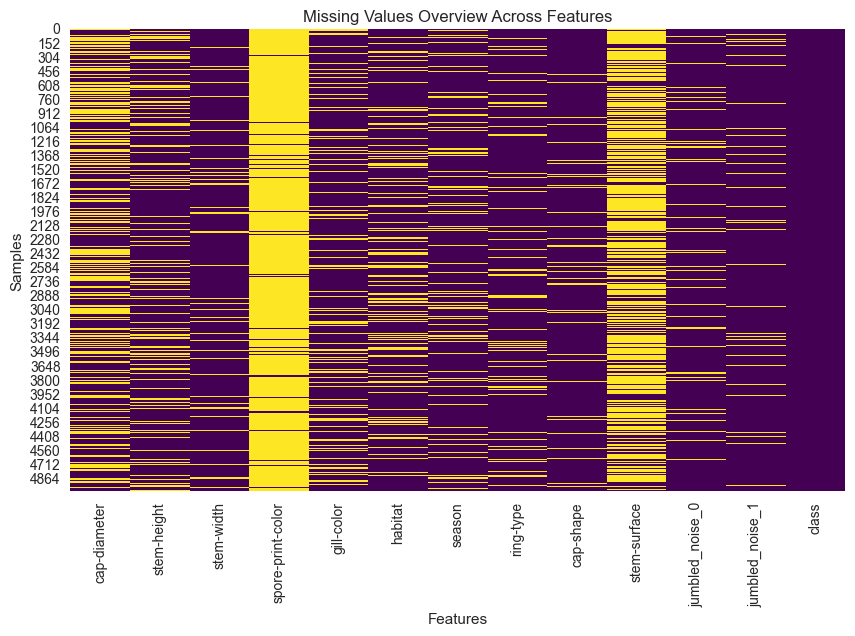

In [47]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Overview Across Features")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.show()

# Missing Data Overview (Missing Values Overview Across Features)
- Extreme Missingness in Specific Columns: spore-print-color is almost completely yellow (~94.8% missing data). stem-surface (~67.2%) and cap-diameter (~40.6%) also have large missing blocks.
- Feature Dropping Recommendation: Columns like spore-print-color carry too little information to be useful and can safely be dropped rather than imputed.
- Imputation Strategy: For features with moderate missingness (such as stem-height, habitat, season, and gill-color at ~11%–20%), imputation (using median for numeric and most frequent for categorical) is essential before feeding them to models like Decision Trees or Random Forests. 

# Noise Columns (jumbled_noise_0, jumbled_noise_1)
- Both head previews and heatmap columns show jumbled_noise_0 and jumbled_noise_1. These are artificial noise features included in the dataset. They should be dropped during preprocessing to prevent models from overfitting on random noise.

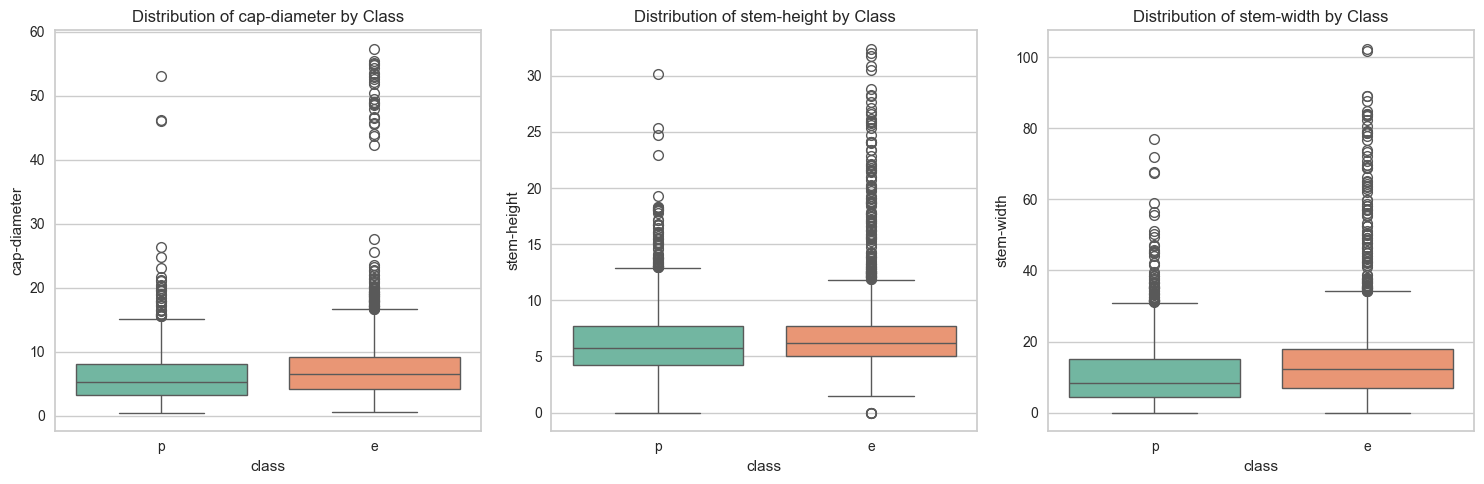

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
num_cols = ["cap-diameter", "stem-height", "stem-width"]

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="class", y=col, ax=ax, palette="Set2", hue="class")
    ax.set_title(f"Distribution of {col} by Class")

plt.tight_layout()
plt.show()

# Numerical Distributions (Distribution of cap-diameter / stem-height / stem-width by Class)
- Edible Mushrooms Are Generally Larger: Edible mushrooms (e) consistently display higher median values and upper quartiles across all three dimensions compared to poisonous ones (p):
  - stem-width: Median is ~12.27 for edible vs. ~8.42 for poisonous.
  - cap-diameter: Median is ~6.56 for edible vs. ~5.33 for poisonous.
  - stem-height: Median is ~6.19 for edible vs. ~5.73 for poisonous.

- Significant Outliers & Overlap: While edible mushrooms lean larger on average, there is heavy overlap between the two classes along with extreme upper outliers, meaning no single numerical metric can separate the classes on its own.

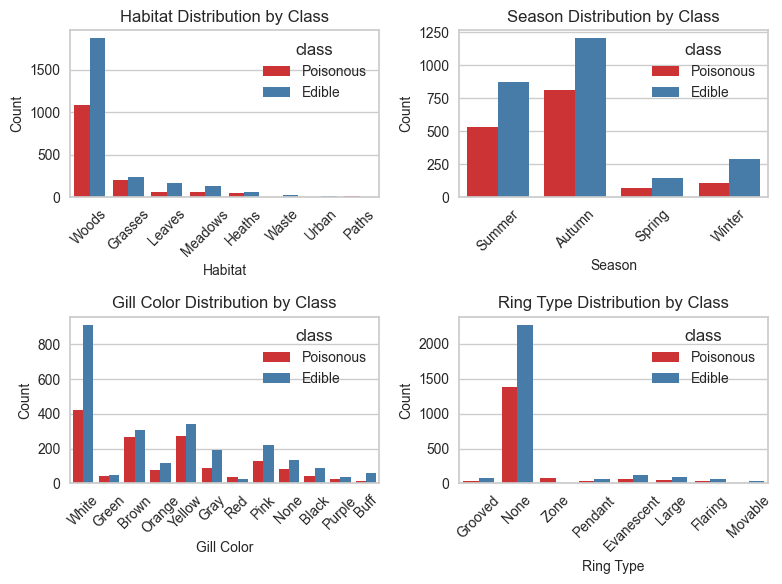

In [ ]:
# Define mappings from metadata 
mappings = {
    "habitat": {
        "g": "Grasses", "l": "Leaves", "m": "Meadows", "p": "Paths",
        "h": "Heaths", "u": "Urban", "w": "Waste", "d": "Woods"
    },
    "season": {
        "s": "Spring", "u": "Summer", "a": "Autumn", "w": "Winter"
    },
    "gill-color": {
        "n": "Brown", "b": "Buff", "g": "Gray", "r": "Green", "p": "Pink",
        "u": "Purple", "e": "Red", "w": "White", "y": "Yellow", "l": "Blue",
        "o": "Orange", "k": "Black", "f": "None"
    },
    "ring-type": {
        "c": "Cobwebby", "e": "Evanescent", "r": "Flaring", "g": "Grooved",
        "l": "Large", "p": "Pendant", "s": "Sheathing", "z": "Zone",
        "y": "Scaly", "m": "Movable", "f": "None", "?": "Unknown"
    },
    "class": {
        "e": "Edible", "p": "Poisonous"
    }
}

# Create a copy for plotting with full category names
df_plot = df.copy()

# Map the class column so legend displays full names
df_plot["class"] = df_plot["class"].map(mappings["class"]).fillna(df_plot["class"])

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
cat_features = ["habitat", "season", "gill-color", "ring-type"]

for ax, feature in zip(axes.flatten(), cat_features):
    # Map feature values to full descriptive names
    df_plot[feature] = df_plot[feature].map(mappings[feature]).fillna(df_plot[feature])
    
    sns.countplot(
        data=df_plot,
        x=feature,
        hue="class",
        ax=ax,
        palette="Set1"
    )
    ax.set_title(f"{feature.replace('-', ' ').title()} Distribution by Class", fontsize=12)
    ax.set_xlabel(feature.replace('-', ' ').title(), fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Categorical Distributions (Habitat, Season, Gill Color, Ring Type)Class
- Imbalance in Key Categories:Ring Type: 
  - The vast majority of observations fall under ring-type == 'f', where edible mushrooms outweigh poisonous ones nearly 2:1.
  - Habitat: Habitat d (woods/woods-like) dominates the dataset, with edible mushrooms making up almost double the poisonous instances. Habitat p (paths) is rare but strongly favors poisonous.
  - Season: Seasons u and a contain most records, both maintaining a consistent ~60/40 split in favor of edible mushrooms.
  - Gill Color: Gill color w (white) is the most prominent category and strongly correlates with edible mushrooms. 

In [51]:
# 1. Dataset laden en opschonen op basis van je inzichten
df_clean = df.drop(columns=['jumbled_noise_0', 'jumbled_noise_1', 'spore-print-color'])

# 2. PyCaret experiment opzetten
exp = ClassificationExperiment()

# PyCaret verzorgt automatisch train/test-split, one-hot encoding en imputatie
exp.setup(
    data=df_clean,
    target='class',
    session_id=42,
    train_size=0.7,       # 70% training data, 20% validation data, 10% test data
    fix_imbalance=True    # Handig als je giftige paddenstoelen zwaarder wilt wegen
)

# 3. Alle geschikte modellen vergelijken in één regel code
best_model = exp.compare_models()

  File "c:\school\AI\Deep Learning\Cloud_AI\CloudAI-Challenge\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,Description,Value
0,Session id,42
1,Target,class
2,Target type,Binary
3,Target mapping,"e: 0, p: 1"
4,Original data shape,"(5000, 10)"
5,Transformed data shape,"(5850, 51)"
6,Transformed train set shape,"(4350, 51)"
7,Transformed test set shape,"(1500, 51)"
8,Numeric features,3
9,Categorical features,6


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7769,0.8127,0.7769,0.7746,0.7717,0.5088,0.5148,0.1160
et,Extra Trees Classifier,0.7531,0.7935,0.7531,0.7493,0.7484,0.4594,0.4632,0.1070
gbc,Gradient Boosting Classifier,0.7423,0.7587,0.7423,0.7403,0.7308,0.4193,0.4334,0.1260
knn,K Neighbors Classifier,0.7237,0.7735,0.7237,0.7313,0.7257,0.4243,0.4266,0.3790
dt,Decision Tree Classifier,0.6877,0.6701,0.6877,0.6894,0.6881,0.3389,0.3394,0.0360
ada,Ada Boost Classifier,0.6749,0.7030,0.6749,0.6719,0.6728,0.3015,0.3021,0.0630
qda,Quadratic Discriminant Analysis,0.6417,0.6888,0.6417,0.6558,0.6232,0.2473,0.2546,0.0350
nb,Naive Bayes,0.6380,0.6352,0.6380,0.6327,0.6154,0.1910,0.2046,0.0320
lr,Logistic Regression,0.6366,0.6766,0.6366,0.6479,0.6402,0.2484,0.2500,0.6210
ridge,Ridge Classifier,0.6354,0.6759,0.6354,0.6446,0.6386,0.2424,0.2435,0.0320
